# Разведочный анализ данных. Датасет Boston Housing.

## 1) Текстовое описание набора данных

**Boston Housing Dataset** — классический набор данных, широко применяемый в задачах регрессии и машинного обучения. Данные были собраны Службой переписи населения США в 1978 году и описывают жилищные условия в различных районах Бостона (штат Массачусетс).

Исходный датасет был опубликован в статье Harrison, D. and Rubinfeld, D.L. *Hedonic prices and the demand for clean air*, J. Environ. Economics & Management, vol.5, 81-102, 1978.

**Целевая задача** — прогнозирование медианной стоимости домов (признак MEDV) в тысячах долларов на основе социально-экономических и экологических характеристик района.

Датасет содержит **506 наблюдений** (районов) и **14 признаков**:

| Признак | Описание |
|---------|----------|
| CRIM | Уровень преступности на душу населения по районам |
| ZN | Доля жилых земель под застройку домами более 25 000 кв. футов (%) |
| INDUS | Доля акров нежилой деловой застройки в районе (%) |
| CHAS | Бинарная переменная: 1, если район граничит с рекой Чарльз, иначе 0 |
| NOX | Концентрация оксидов азота (частей на 10 миллионов) |
| RM | Среднее количество комнат в доме |
| AGE | Доля домов, построенных до 1940 года, среди занятых домовладельцами (%) |
| DIS | Взвешенное расстояние до пяти центров занятости Бостона |
| RAD | Индекс доступности радиальных автомагистралей |
| TAX | Ставка налога на имущество на $10 000 |
| PTRATIO | Соотношение учеников и учителей в районе |
| B | 1000(Bk - 0.63)², где Bk — доля афроамериканцев в районе |
| LSTAT | Доля населения с низким социально-экономическим статусом (%) |
| MEDV | **Целевой признак**: медианная стоимость домов в тысячах долларов |

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

%matplotlib inline
sns.set(style="ticks")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Загрузка данных

In [2]:
data = pd.read_csv('boston.csv', sep=',')
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## 2) Основные характеристики датасета

In [3]:
print(f'Размер датасета: {data.shape[0]} строк, {data.shape[1]} колонок')

Размер датасета: 506 строк, 14 колонок


In [4]:
# Список колонок с типами данных
data.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

In [5]:
# Проверка наличия пропущенных значений
missing = data.isnull().sum()
print('Количество пропущенных значений по колонкам:')
print(missing)

Количество пропущенных значений по колонкам:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


Пропущенных значений в датасете нет — все признаки заполнены полностью.

In [6]:
# Основные статистические характеристики
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


**Наблюдения по статистике:**
- Признак CRIM (уровень преступности) имеет очень большой разброс: от ~0 до 89, при среднем ~3.6 — присутствуют выбросы.
- Признак ZN (зонирование) содержит много нулей: медиана равна 0, что говорит о том, что большинство районов не имеют крупных жилых зон.
- Признак CHAS бинарный: всего два уникальных значения — 0 и 1.
- MEDV (целевой признак) варьируется от 5 до 50 тысяч долларов со средним ~22.5.

In [7]:
# Уникальные значения бинарного признака CHAS
print('Уникальные значения CHAS:', data['CHAS'].unique())
print('Распределение CHAS:')
print(data['CHAS'].value_counts())

Уникальные значения CHAS: [0 1]
Распределение CHAS:
CHAS
0    471
1     35
Name: count, dtype: int64


In [8]:
# Количество дубликатов
dup_count = data.duplicated().sum()
print(f'Количество дублирующихся строк: {dup_count}')

Количество дублирующихся строк: 0


## 3) Визуальное исследование датасета

### 3.1 Распределение целевого признака MEDV

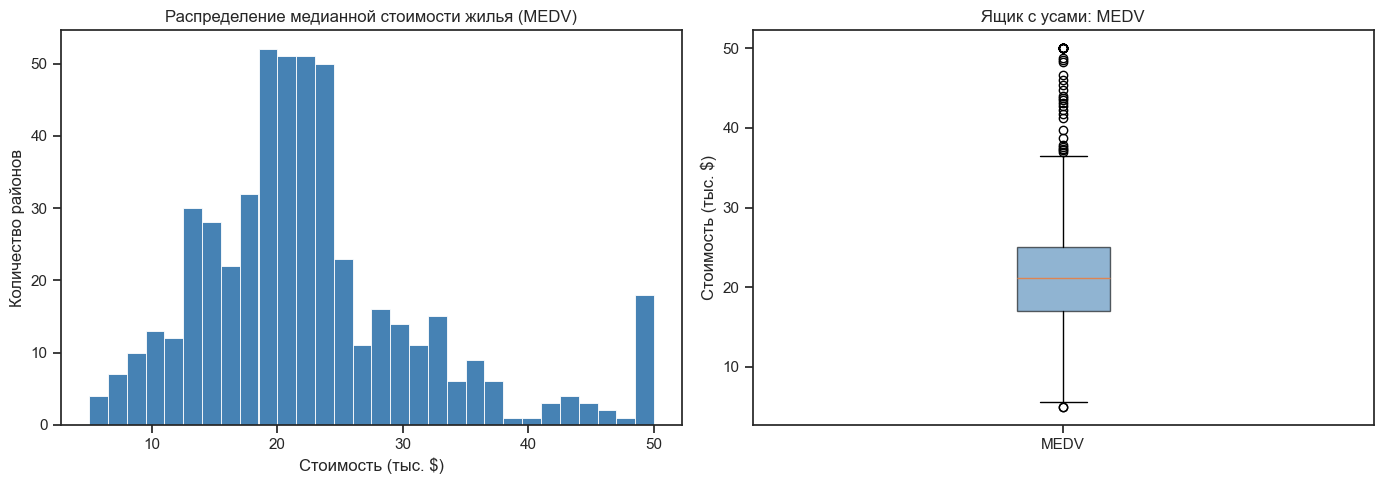

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(data['MEDV'], bins=30, color='steelblue', edgecolor='white', linewidth=0.6)
axes[0].set_title('Распределение медианной стоимости жилья (MEDV)')
axes[0].set_xlabel('Стоимость (тыс. $)')
axes[0].set_ylabel('Количество районов')

# Ящик с усами
axes[1].boxplot(data['MEDV'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Ящик с усами: MEDV')
axes[1].set_ylabel('Стоимость (тыс. $)')
axes[1].set_xticklabels(['MEDV'])

plt.tight_layout()
plt.show()

Распределение целевого признака MEDV имеет небольшую правостороннюю асимметрию и заметный пик на значении 50 000 — это верхний предел значений в датасете (цензурированные данные).

### 3.2 Гистограммы всех числовых признаков

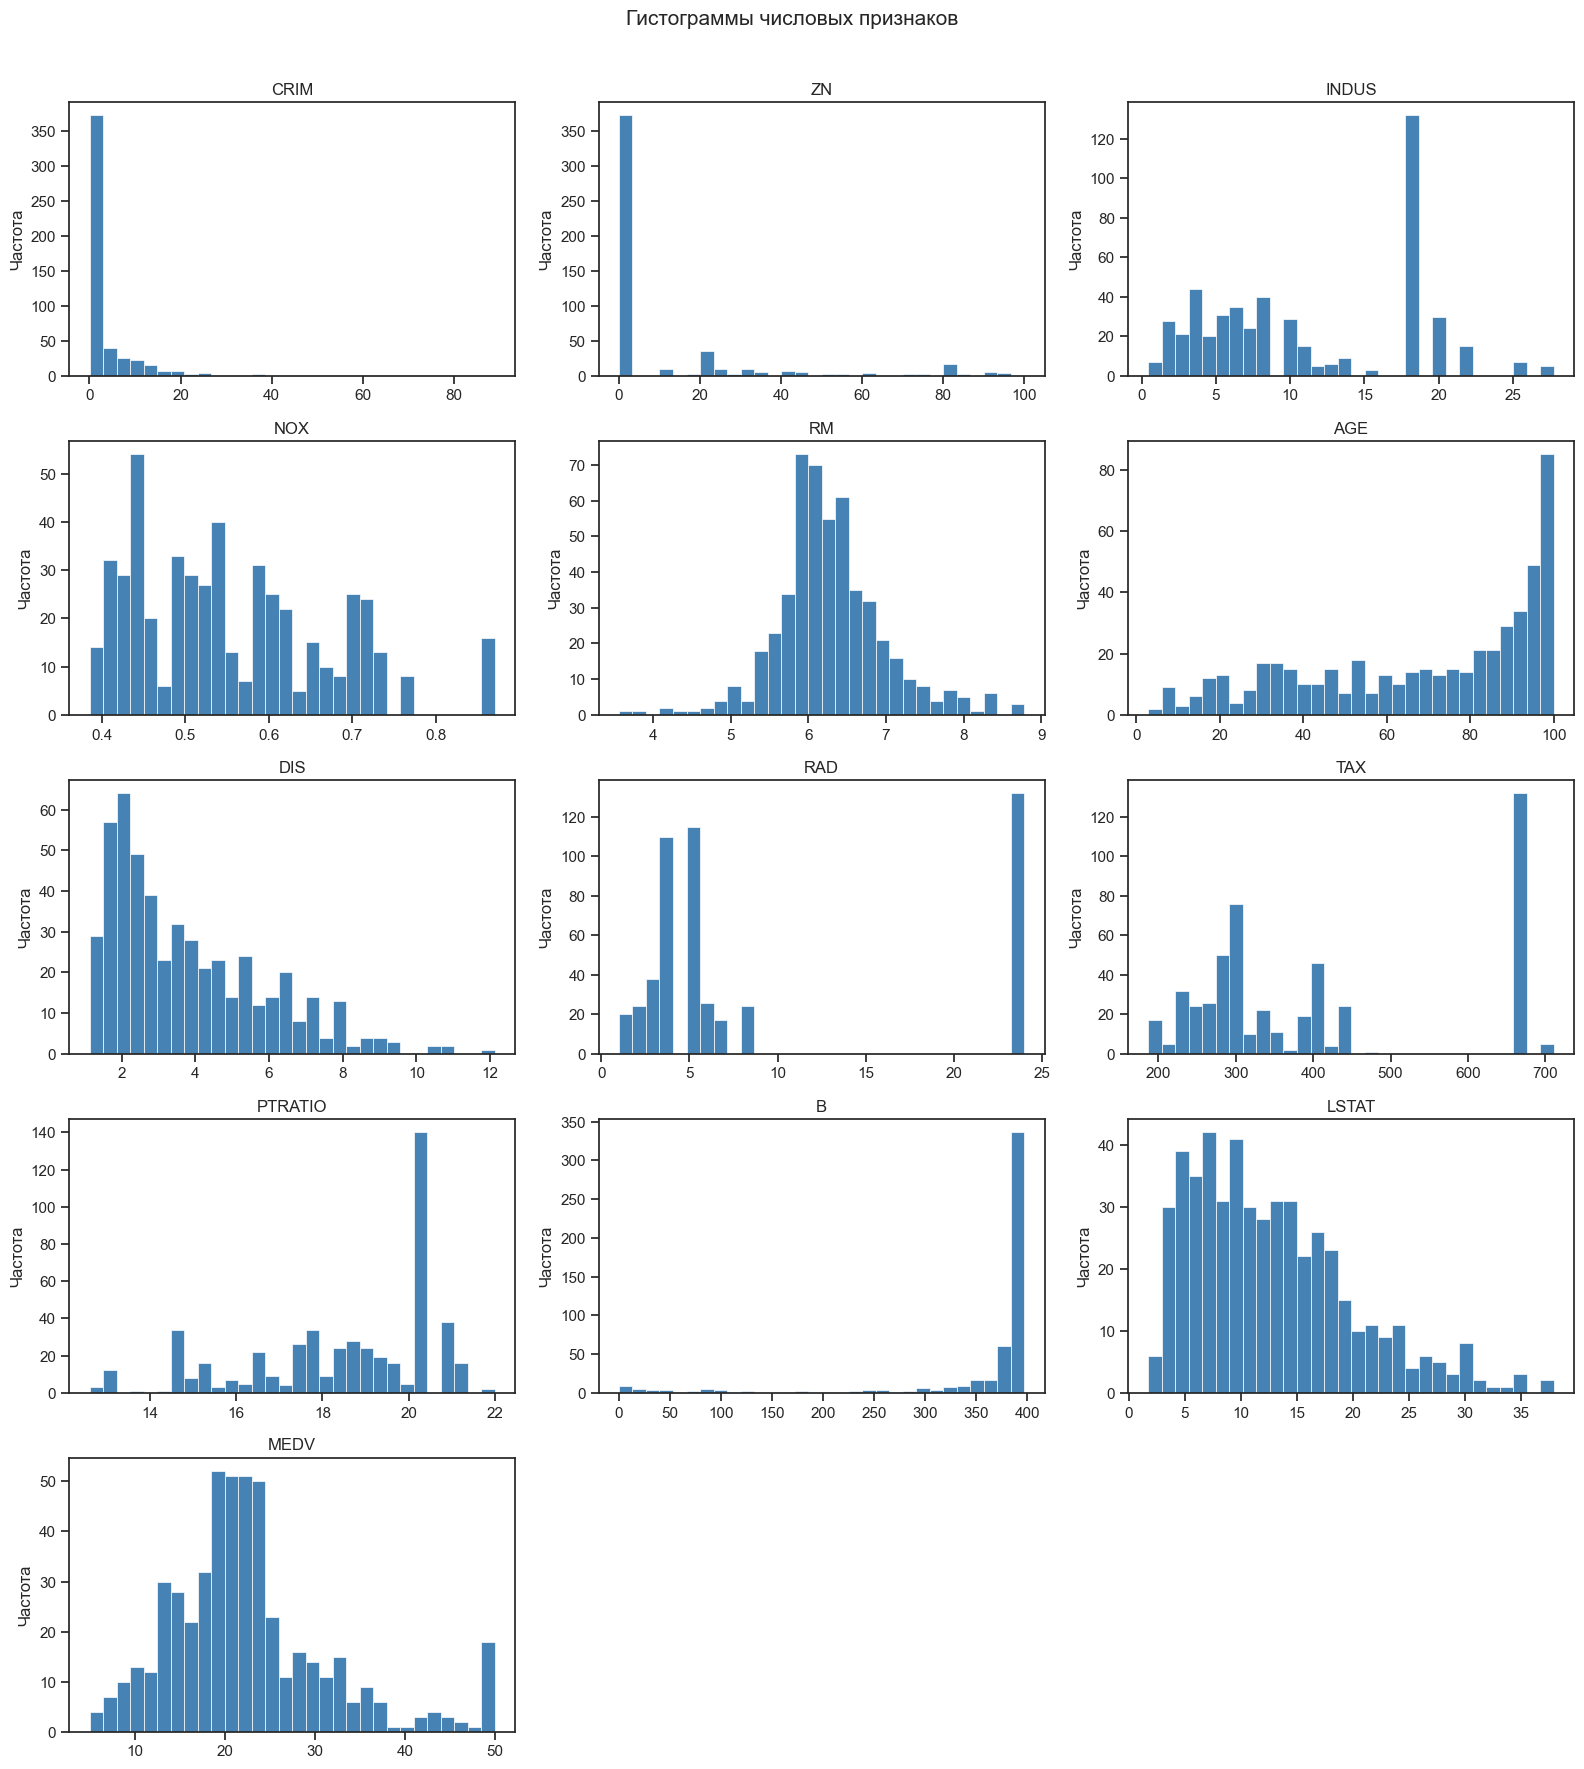

In [10]:
numeric_cols = [c for c in data.columns if c != 'CHAS']

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(data[col], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Частота')

# Скрываем лишние оси
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Гистограммы числовых признаков', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Диаграммы «ящик с усами» для выявления выбросов

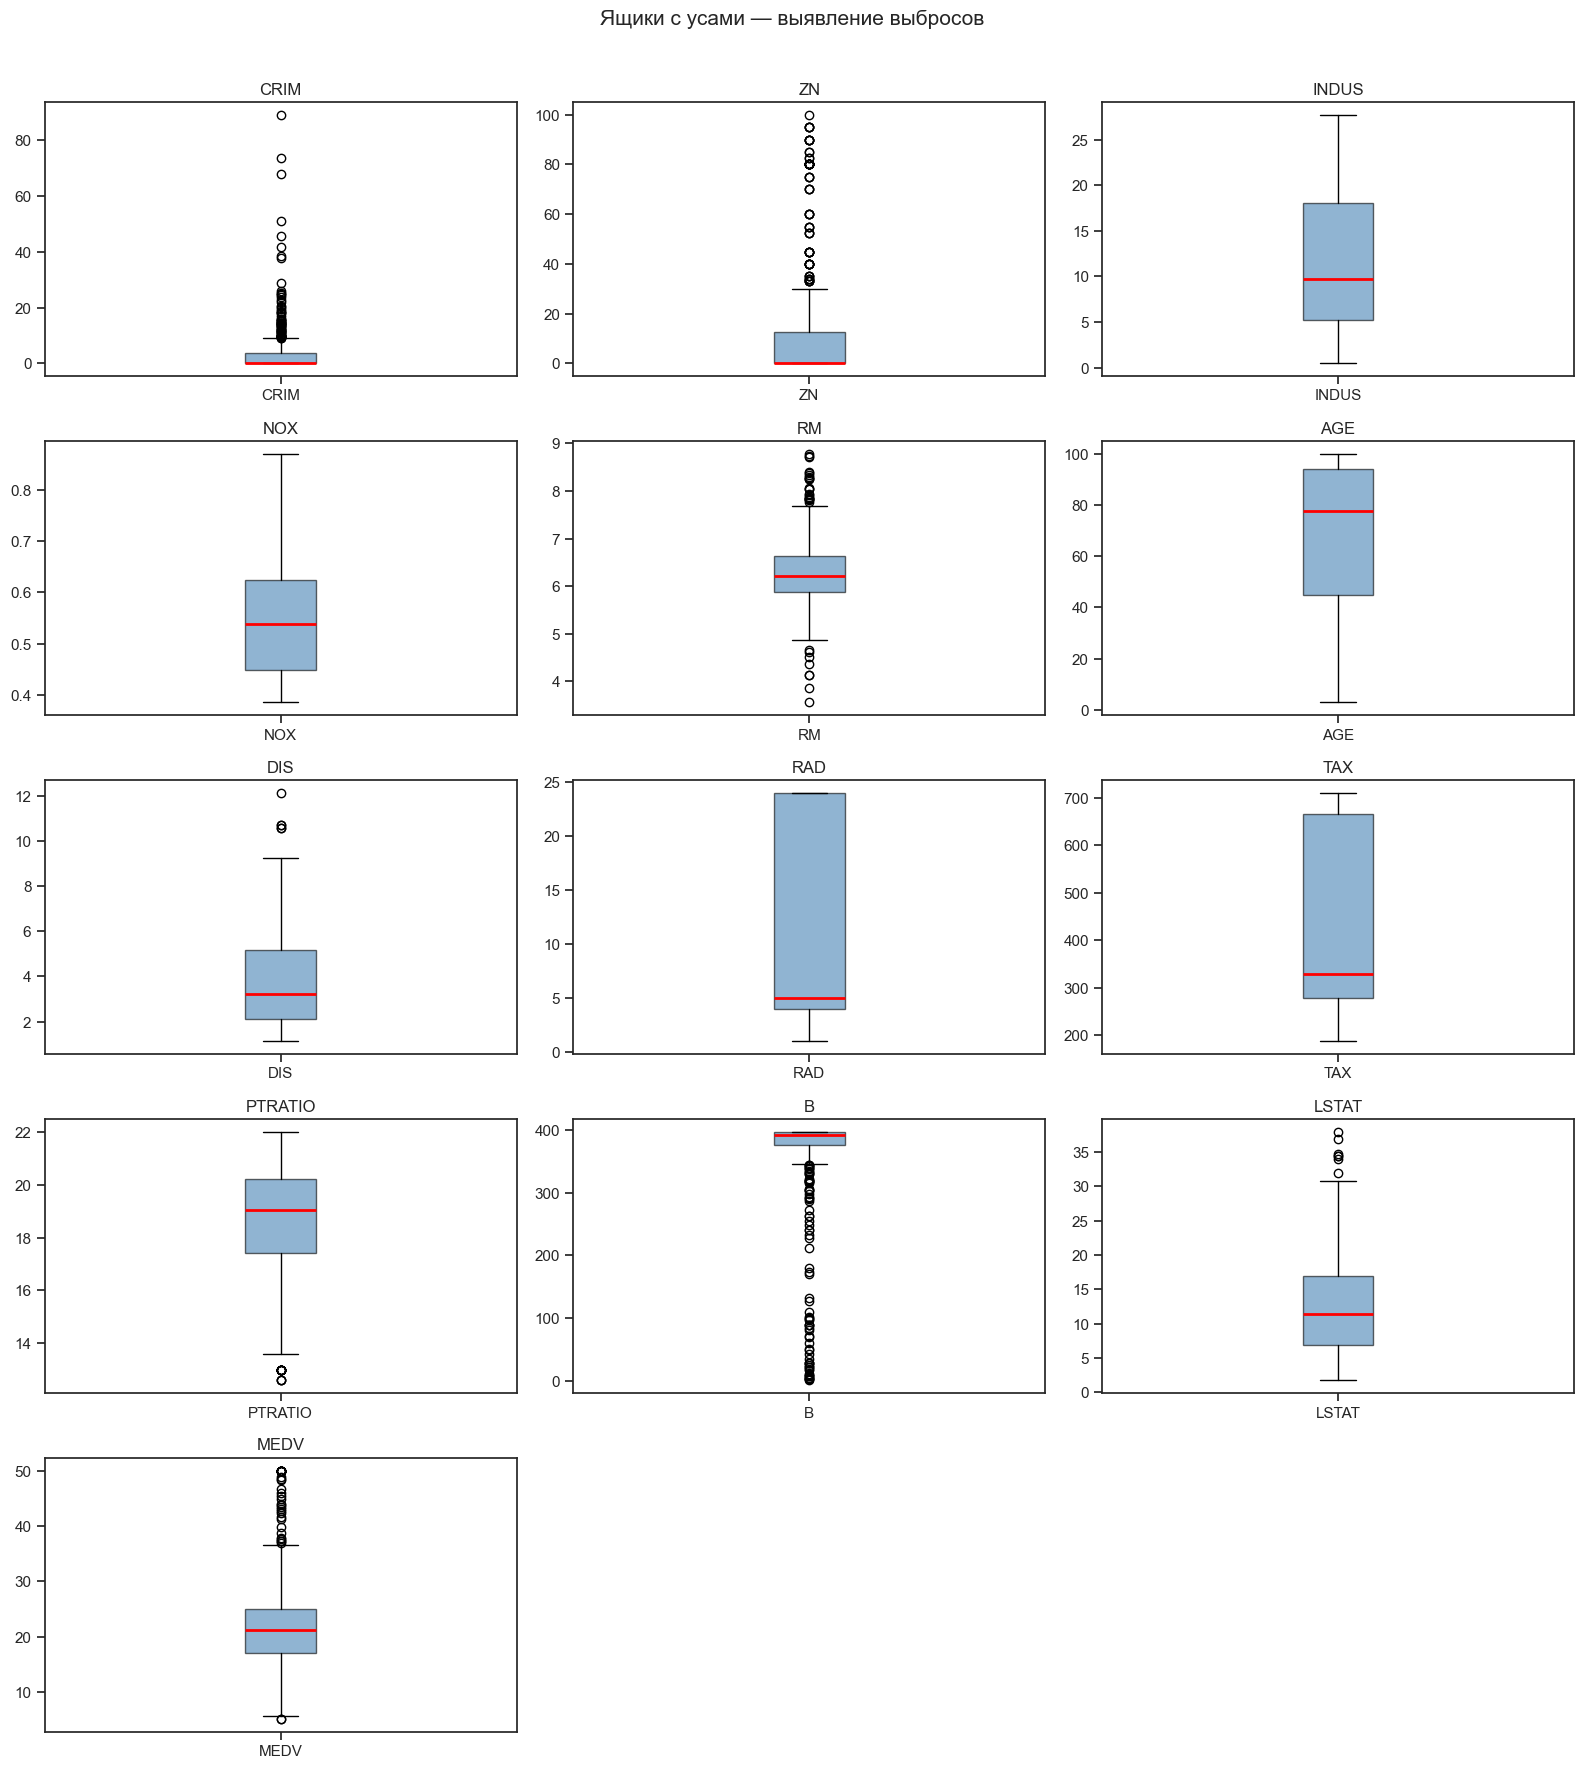

In [11]:
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(data[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_xticklabels([col])

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Ящики с усами — выявление выбросов', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Признаки CRIM, ZN, B, LSTAT и MEDV содержат заметное количество выбросов, что подтверждается большим разбросом в статистике.

### 3.4 Распределение признака CHAS (близость к реке Чарльз)

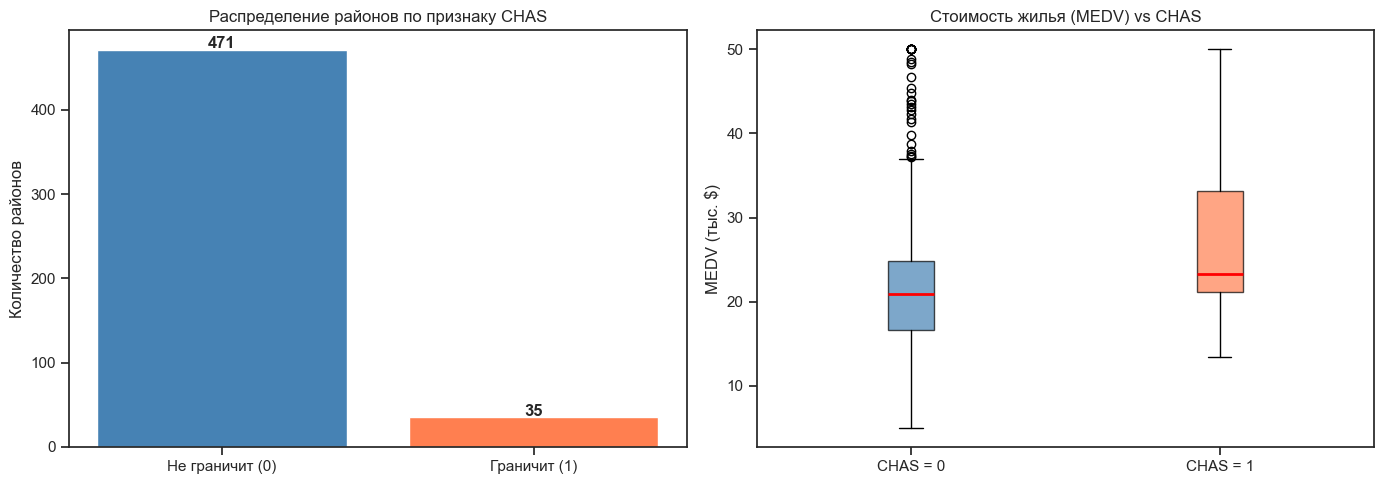

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Столбчатая диаграмма
chas_counts = data['CHAS'].value_counts()
axes[0].bar(['Не граничит (0)', 'Граничит (1)'], chas_counts.values,
            color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Распределение районов по признаку CHAS')
axes[0].set_ylabel('Количество районов')
for idx, val in enumerate(chas_counts.values):
    axes[0].text(idx, val + 2, str(val), ha='center', fontweight='bold')

# Boxplot MEDV по CHAS
chas_0 = data[data['CHAS'] == 0]['MEDV']
chas_1 = data[data['CHAS'] == 1]['MEDV']
bp = axes[1].boxplot([chas_0, chas_1], patch_artist=True,
                      boxprops=dict(alpha=0.7),
                      medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
axes[1].set_xticklabels(['CHAS = 0', 'CHAS = 1'])
axes[1].set_title('Стоимость жилья (MEDV) vs CHAS')
axes[1].set_ylabel('MEDV (тыс. $)')

plt.tight_layout()
plt.show()

Лишь 35 районов из 506 граничат с рекой Чарльз. При этом медианная стоимость жилья в таких районах несколько выше.

### 3.5 Scatter-plots: зависимость признаков от MEDV

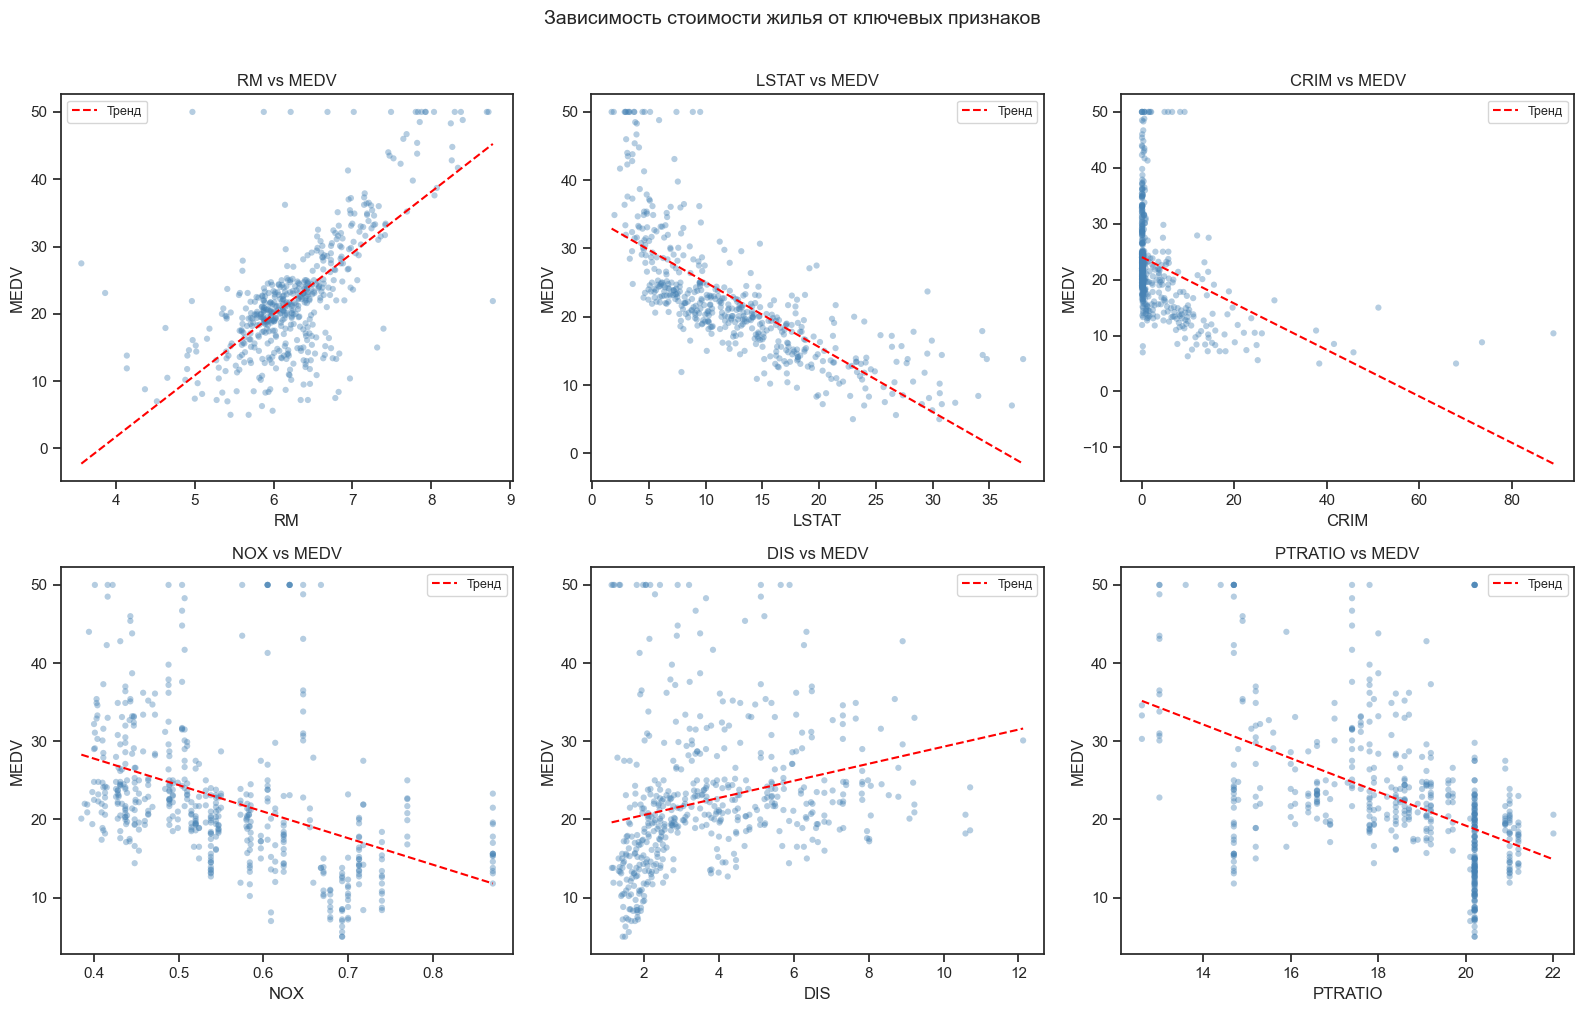

In [13]:
key_features = ['RM', 'LSTAT', 'CRIM', 'NOX', 'DIS', 'PTRATIO']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].scatter(data[col], data['MEDV'], alpha=0.4, color='steelblue', edgecolors='none', s=20)
    # Линия тренда
    z = np.polyfit(data[col], data['MEDV'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[col].min(), data[col].max(), 200)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=1.5, linestyle='--', label='Тренд')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('MEDV')
    axes[i].set_title(f'{col} vs MEDV')
    axes[i].legend(fontsize=9)

plt.suptitle('Зависимость стоимости жилья от ключевых признаков', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Наблюдения:**
- RM (количество комнат) демонстрирует выраженную **положительную** линейную зависимость с MEDV.
- LSTAT (низкий соц. статус) показывает **отрицательную** нелинейную зависимость: чем выше доля бедного населения, тем ниже цены.
- CRIM, NOX, PTRATIO также отрицательно коррелируют со стоимостью жилья.

### 3.6 Violin-plots для числовых признаков по CHAS

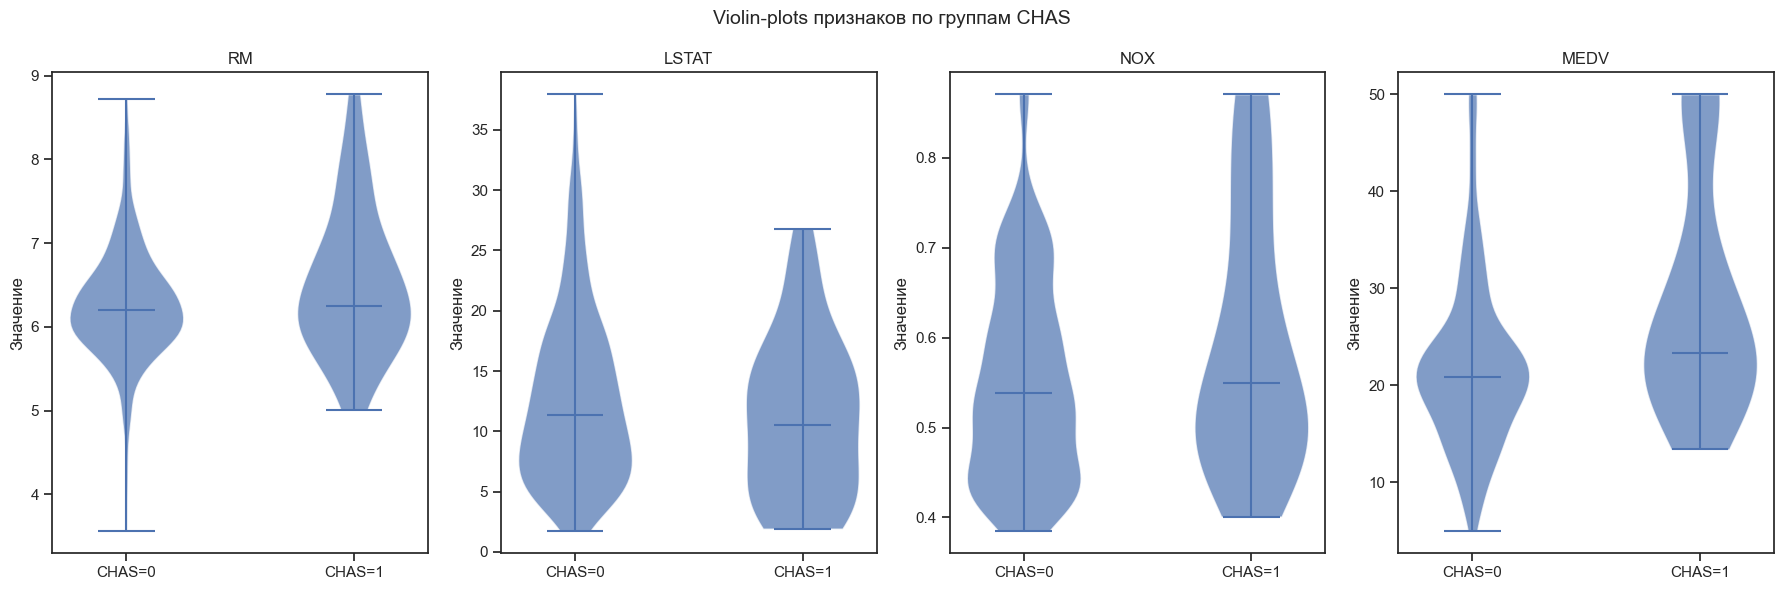

In [14]:
features_violin = ['RM', 'LSTAT', 'NOX', 'MEDV']

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, col in enumerate(features_violin):
    groups = [data[data['CHAS'] == 0][col].values,
              data[data['CHAS'] == 1][col].values]
    parts = axes[i].violinplot(groups, positions=[0, 1], showmedians=True)
    for pc in parts['bodies']:
        pc.set_alpha(0.7)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['CHAS=0', 'CHAS=1'])
    axes[i].set_title(col)
    axes[i].set_ylabel('Значение')

plt.suptitle('Violin-plots признаков по группам CHAS', fontsize=14)
plt.tight_layout()
plt.show()

### 3.7 Pairplot ключевых признаков

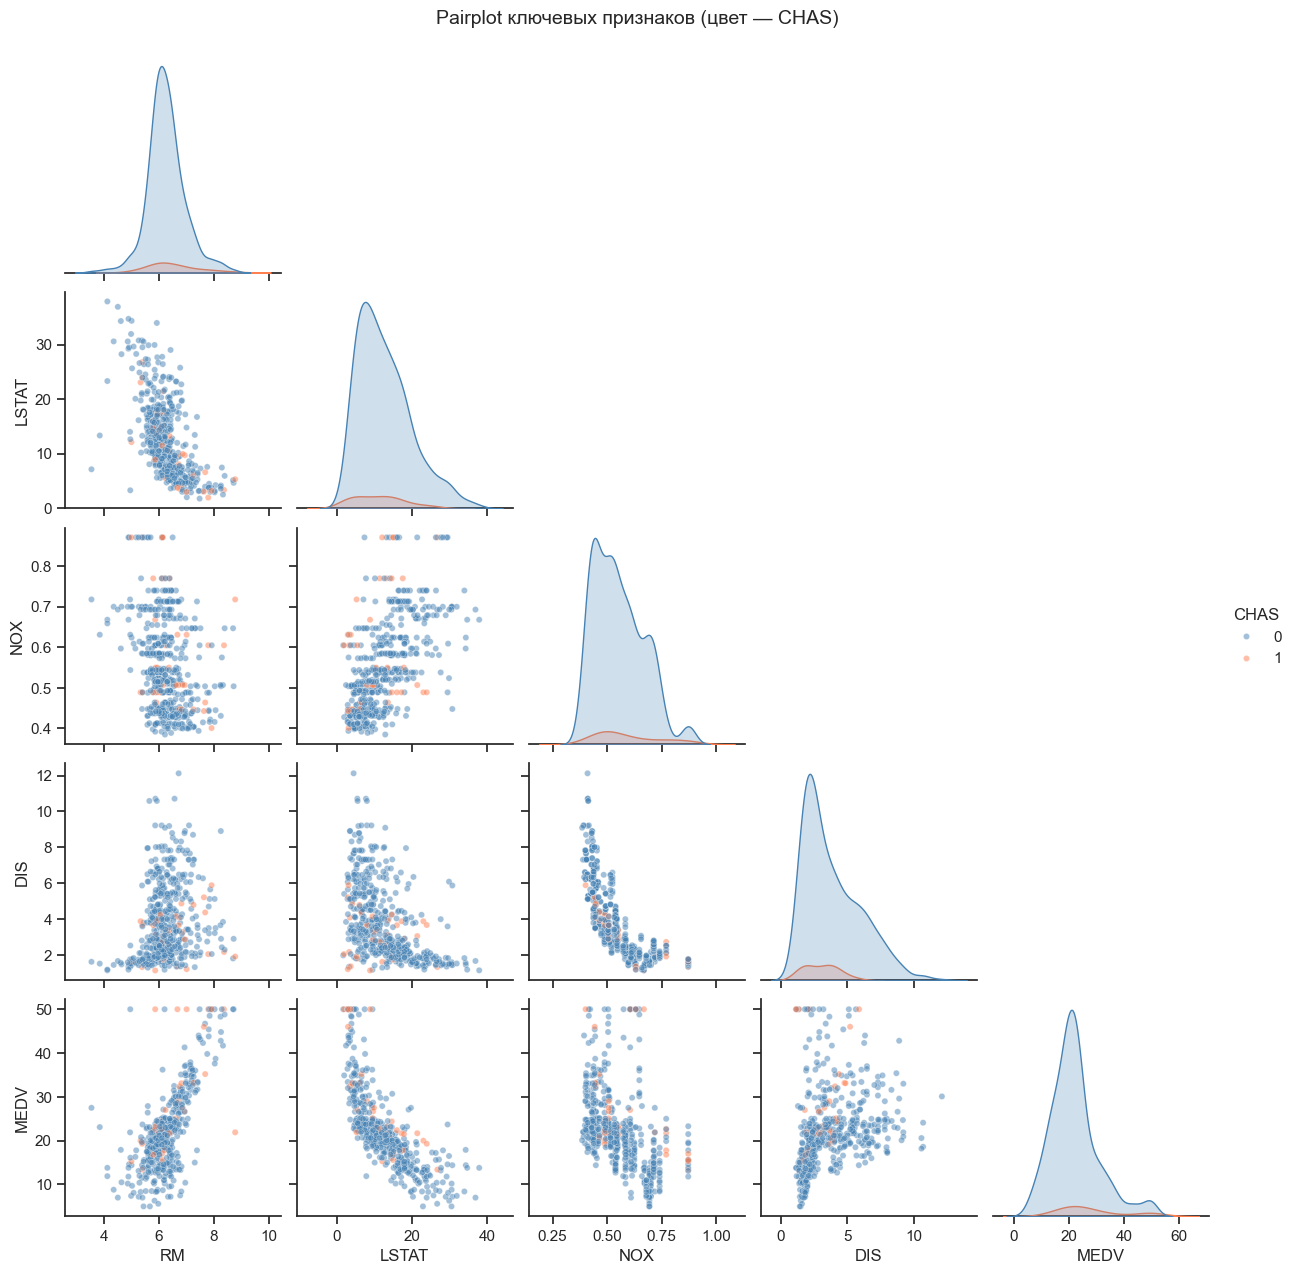

In [15]:
pairplot_cols = ['RM', 'LSTAT', 'NOX', 'DIS', 'MEDV']
pp_data = data[pairplot_cols].copy()
pp_data['CHAS'] = data['CHAS'].astype(str)

g = sns.pairplot(pp_data, hue='CHAS', corner=True,
                 plot_kws={'alpha': 0.5, 's': 20},
                 palette={'0': 'steelblue', '1': 'coral'})
g.fig.suptitle('Pairplot ключевых признаков (цвет — CHAS)', y=1.02, fontsize=14)
plt.show()

## 4) Информация о корреляции признаков

### 4.1 Матрица корреляции Пирсона

In [16]:
corr_matrix = data.corr()
corr_matrix

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


### 4.2 Тепловая карта корреляций

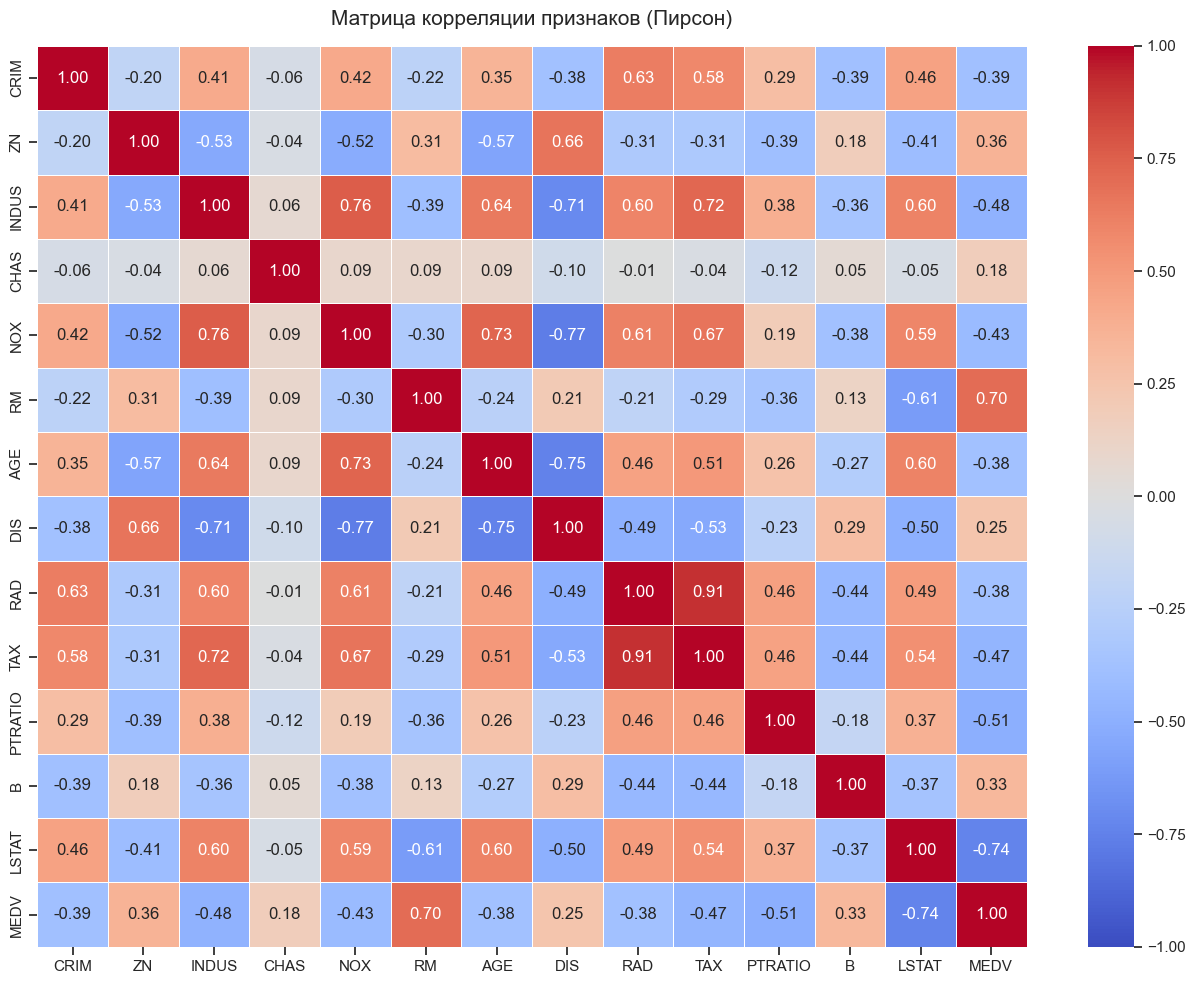

In [17]:
fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Матрица корреляции признаков (Пирсон)', fontsize=15, pad=15)
plt.tight_layout()
plt.show()

### 4.3 Корреляция признаков с целевой переменной MEDV

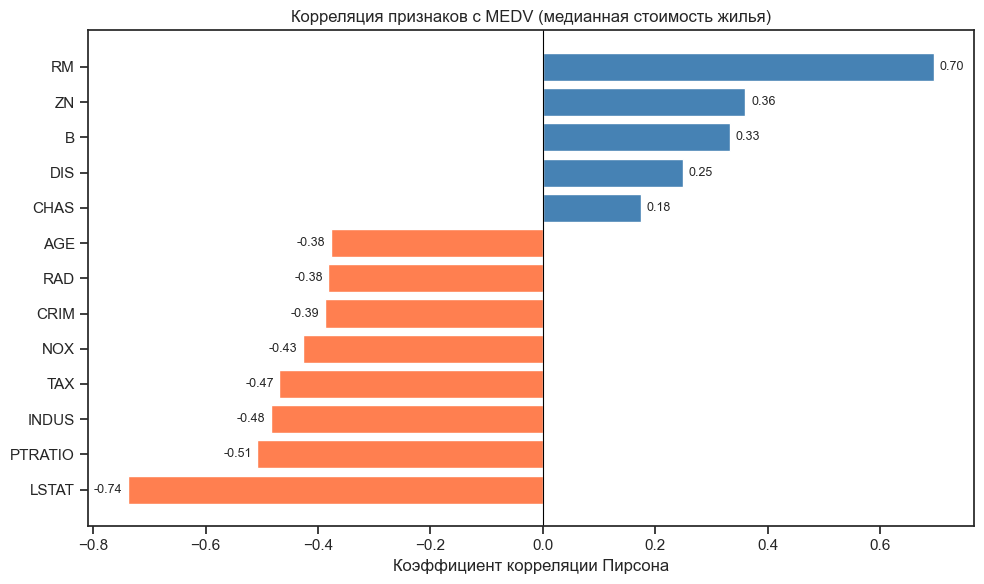

In [18]:
medv_corr = corr_matrix['MEDV'].drop('MEDV').sort_values()

colors = ['coral' if v < 0 else 'steelblue' for v in medv_corr.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(medv_corr.index, medv_corr.values, color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Коэффициент корреляции Пирсона')
ax.set_title('Корреляция признаков с MEDV (медианная стоимость жилья)')

for bar, val in zip(bars, medv_corr.values):
    offset = 0.01 if val >= 0 else -0.01
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

### 4.4 Топ признаков по абсолютному значению корреляции с MEDV

In [19]:
top_corr = medv_corr.abs().sort_values(ascending=False)
print('Признаки, отсортированные по силе корреляции с MEDV:')
for feat, val in top_corr.items():
    direction = '+' if medv_corr[feat] > 0 else '-'
    print(f'  {feat:<10} {direction}  |r| = {val:.3f}')

Признаки, отсортированные по силе корреляции с MEDV:
  LSTAT      -  |r| = 0.738
  RM         +  |r| = 0.695
  PTRATIO    -  |r| = 0.508
  INDUS      -  |r| = 0.484
  TAX        -  |r| = 0.469
  NOX        -  |r| = 0.427
  CRIM       -  |r| = 0.388
  RAD        -  |r| = 0.382
  AGE        -  |r| = 0.377
  ZN         +  |r| = 0.360
  B          +  |r| = 0.333
  DIS        +  |r| = 0.250
  CHAS       +  |r| = 0.175


### 4.5 Мультиколлинеарность: сильно коррелирующие пары признаков

In [20]:
threshold = 0.7
print(f'Пары признаков с |r| > {threshold} (мультиколлинеарность):')
found = False
features = [c for c in data.columns if c != 'MEDV']
for i in range(len(features)):
    for j in range(i + 1, len(features)):
        r = corr_matrix.loc[features[i], features[j]]
        if abs(r) > threshold:
            print(f'  {features[i]:<10} <-> {features[j]:<10}  r = {r:.3f}')
            found = True
if not found:
    print('  Не найдено.')

Пары признаков с |r| > 0.7 (мультиколлинеарность):
  INDUS      <-> NOX         r = 0.764
  INDUS      <-> DIS         r = -0.708
  INDUS      <-> TAX         r = 0.721
  NOX        <-> AGE         r = 0.731
  NOX        <-> DIS         r = -0.769
  AGE        <-> DIS         r = -0.748
  RAD        <-> TAX         r = 0.910


### 4.6 Корреляция Спирмена

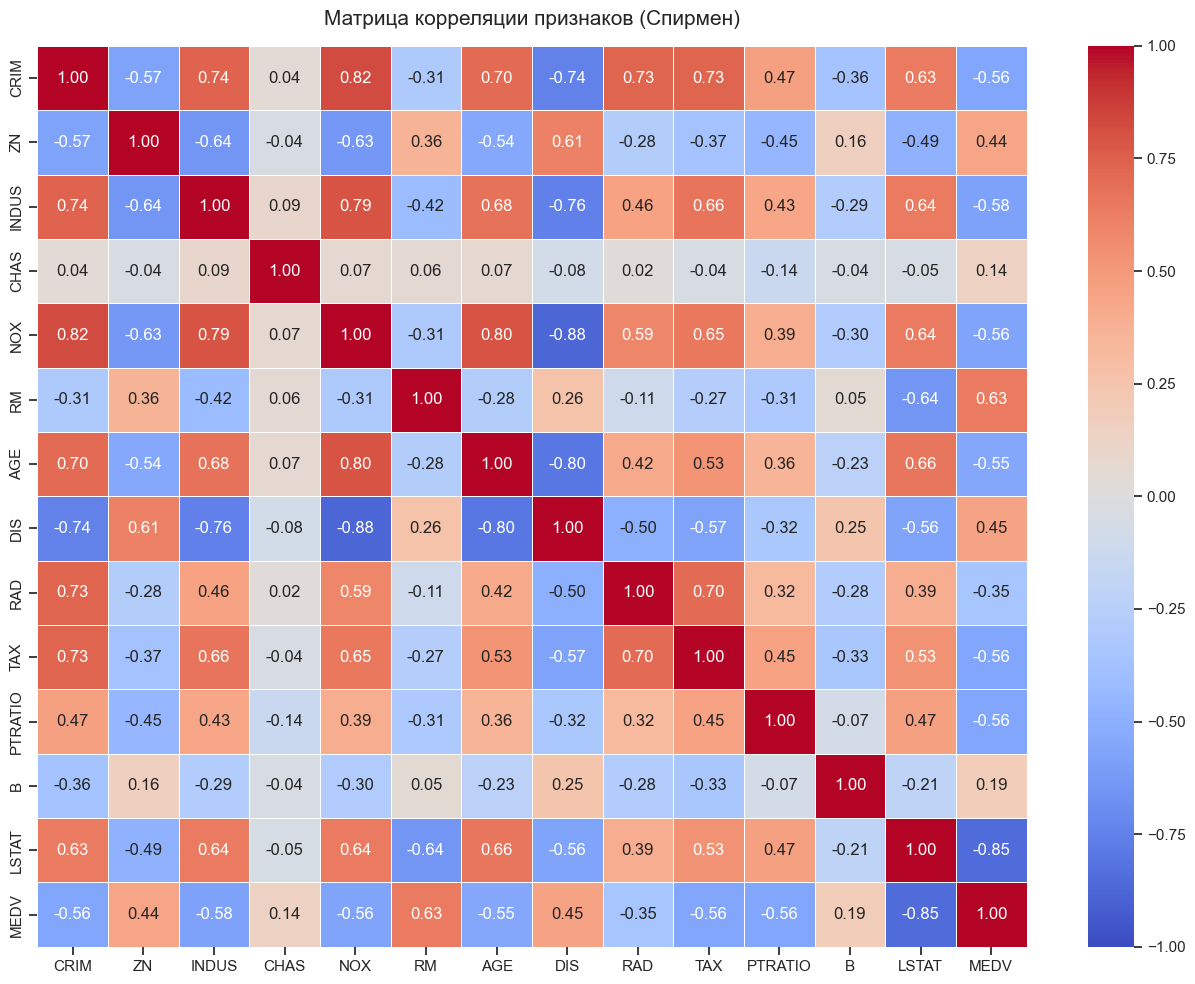

In [21]:
spearman_corr = data.corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Матрица корреляции признаков (Спирмен)', fontsize=15, pad=15)
plt.tight_layout()
plt.show()

### 4.7 Сравнение Пирсона и Спирмена для MEDV

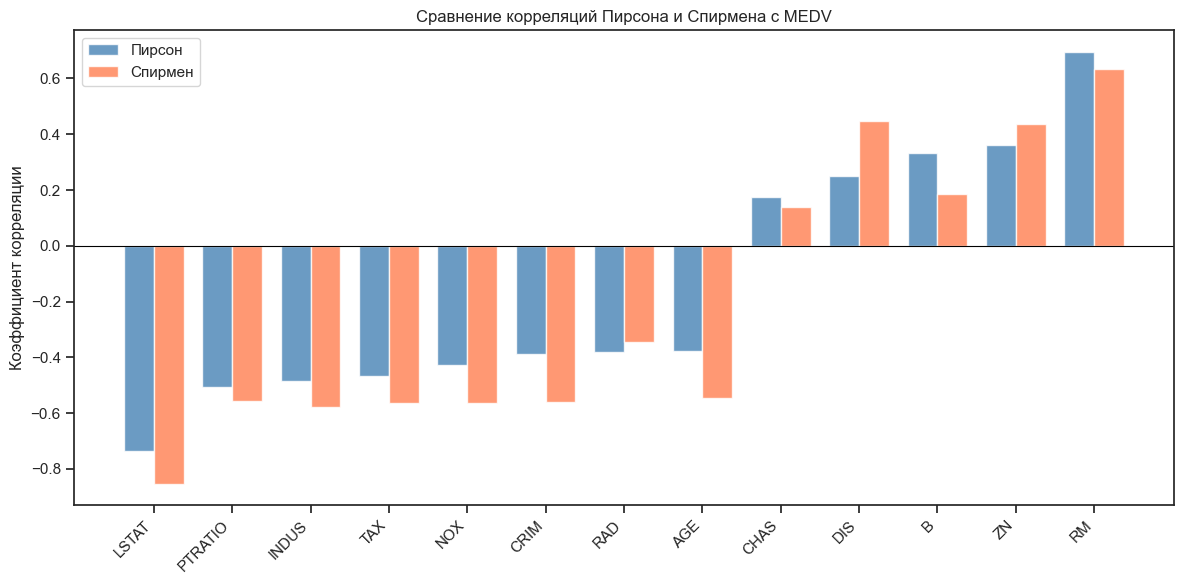

In [22]:
pearson_medv  = corr_matrix['MEDV'].drop('MEDV').sort_values()
spearman_medv = spearman_corr['MEDV'].drop('MEDV').reindex(pearson_medv.index)

x = np.arange(len(pearson_medv))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width / 2, pearson_medv.values,  width, label='Пирсон',  color='steelblue', alpha=0.8)
ax.bar(x + width / 2, spearman_medv.values, width, label='Спирмен', color='coral',     alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(pearson_medv.index, rotation=45, ha='right')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Коэффициент корреляции')
ax.set_title('Сравнение корреляций Пирсона и Спирмена с MEDV')
ax.legend()

plt.tight_layout()
plt.show()

## Выводы

1. **Датасет** содержит 506 наблюдений и 14 признаков, пропущенных значений нет.

2. **Распределения**: большинство признаков имеют скошенные распределения; CRIM, ZN, B содержат значительные выбросы.

3. **Сильнейшие предикторы MEDV**:
   - LSTAT (−0.74) — чем больше бедного населения, тем ниже цены.
   - RM (+0.70) — количество комнат положительно влияет на стоимость.

4. **Мультиколлинеарность**: выявлены пары TAX–RAD, NOX–INDUS, NOX–AGE, DIS–AGE с высокой взаимной корреляцией. Это важно учитывать при построении линейных моделей.

5. **Корреляция Спирмена** даёт схожие результаты, но местами сильнее (например, для LSTAT и DIS) — признак нелинейных зависимостей в данных.